____
____
<h1 align="center">
<font color=#18453b>
Yukawa HNC Solver
</font>
</h1> 


<h4 align="center">
18 May 2021
</h4>

____
____

This Jupyter notebook provides the capability to obtain rapid solutions of the [hypernetted chain (HNC) equations](https://en.wikipedia.org/wiki/Hypernetted-chain_equation) (closure and Ornstein-Zernicke equations) for 3D system.  
The input you will need to have at hand are:  
- the dilute pair correlation function $g_{dil}(r)$
- Packing fraction $\eta$. 
- Grid parameters.  
- Numerical parameter to help convergence: $\alpha$, useful for long range potential. ($\alpha = 0$ for the sheared system since direct correlation function is a short range function)

All the length are in unit of the HS diameter.  

The basic physical model is a many-body system of particles interacting through a pair interaction of the form:         
$$ u(r) = + \infty \; \; \; \; \; se \; \; r < 1$$  
$$ u(r) = - log( c_{2Body}(r) + 1 ) \; \; \; \; \; se \; \; r > 1 .$$


Let's write HNC equations in terms of our dimensionless units:
$$\gamma(k) = \frac{\rho^* c^2(k)}{1 - \rho^* c(k)},$$   
$$g(r) = e^{-u(r) + \gamma(r)},$$   
where $\rho^* = \frac{6}{\pi} \; \eta.$


Actually the code is written in terms of the short range pair correlation, following the Springer method, in order to allow convergence for long range potential, i.e. Coulomb potential. 
The short range function are: 
$$ \gamma_s(r) = \gamma(r) - u_l(r)$$

$$ c_s(r) = c(r) + u_l(r)$$  

$$ u_s(r) = u(r) - u_l(r),$$

where the long range potential is defined as: 
$$u_l(r) = u(r) (1- e^{-\alpha r}).$$

One can rewrite the HNC equations in terms of the short range function:  
$$ \gamma_s(k) = \frac{\rho c_s(k) c(k) - u_l(k)}{1 - \rho c(k)},$$  

$$g(r) = exp[ \gamma_s(r) - u_s(r) ].$$


____
### <a id="top"></a> Questi link ti permettono di muoverti rapidamente all'interno del notebook.
* [Fourier transform routines.](#Fourier_routines)
* [Set up grids.](#grids)
* [Setting input files and $\eta$.](#pot_parameters)
* [Setting up potential and initial conditions.](#potential_ICs)
* [Main loop](#main_loop)
* [Save the results](#saving)

In [66]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("bmh")
plt.rcParams.update({'font.size': 24})

from scipy import fftpack
# %matplotlib inline
# %matplotlib notebook
import seaborn as sns

____
### <a id="grids"></a> Set up grids, with inputs

In [67]:
# run parameters
num_iterations = 350
alpha = 0
#N_bins =
#Rmax
#Contact region
#N_bins = 250000
#R_max = 25
#S(0) vs Pe
#N_bins = 100000
#R_max = 100
#r binning modifiable
N_bins = 5000
R_max = 50

del_r = R_max/N_bins
print(del_r)
#To plot g(r) 
#r_array = np.linspace(del_r/2,R_max-del_r/2,N_bins)
#Better contact region
r_array = np.linspace(del_r/2+5e-5,R_max-del_r/2+5e-5,N_bins)
energy_iter = np.zeros(num_iterations)      #Excess Energy per Particle
pressure_iter = np.zeros(num_iterations)    #Dimensionless Pressure
#In order to compute pressure for hard-core pair potential
idx = (np.abs(r_array - 1)).argmin()
if(r_array[idx]< 1):
    idx = idx+1

# k binning
del_k = np.pi/(N_bins*del_r)
K_max = del_k*N_bins
k_array = np.linspace(del_k/2,K_max-del_k/2,N_bins)

# precompute factors 
fact_r_2_k = 2*np.pi*del_r                 
fact_k_2_r = del_k/(4.*np.pi**2)

0.01


____
### <a id="Fourier_routines"></a> Fourier Transforms  
Let's write the Fourier trasform for spherically simmetric function:  
$$ \tilde{f}(k) = \frac{4 \pi}{k}   \int_{0}^{\infty} \; sin(kr) \; r \; f(r) \; dr,$$ 
$$ f(r) = \frac{1}{2 \pi^2 r}   \int_{0}^{\infty} \; sin(kr) \; k \; \tilde{f}(k) \; dk.$$

We computed these Fourier Trasform using DST(discrete sine transform) of the 4th type:  
$X_k = \sum_{0}^{N-1} x_{n} \sin \left( \; \frac{\pi}{N} \; \left(n + \frac{1}{2} \right) \; \left( k + \frac{1}{2} \right) \; \right), $  
dove k = 0, ..., N-1.  
We chose the fourth type since the points of the grid are the center of the bin, moreover the second type of DST has numerical instabilities.  

In [68]:
# f(k) = FT[f(r)]
def FT_r_2_k(input_array):
    from_dst = fact_r_2_k*fftpack.dst(r_array*input_array,type=4)     #Modified
    return from_dst/k_array

# f(r) = IFT[f(k)]
def FT_k_2_r(input_array):
    from_idst = fact_k_2_r*fftpack.idst(k_array*input_array,type=4)   #Modified
    return from_idst/r_array

____
<a id="pot_parameters"></a> Let's set the physical parameters of the system.

In [69]:
c_File = 'fourier'  #Initial condition
g_dil = 'g_EqGrid_Nohydro_Yukawa_deltar_0p01_Pe10_kappa2_Gamma100.in' #Dilute pcf

phi = 0.3
dimless_dens = 6/np.pi * phi #max 1.909859317102744
beta = 0.5 #Mixing parameters to improve convergence

### Define Potential and Initial Guess
<a id="potential_ICs"></a>
____
In this section there are the functions to initialize the pair interaction potential (for r >1) and the direct correlation fucntion.  
The hard-core pair potential is included in the HNC function in the main.   

In [70]:
#Potential initialization
pmf = -np.log( np.loadtxt(g_dil,usecols=(1)) )
u_tmp = np.zeros(N_bins)
j = 0
for i in range(N_bins):  
    if(r_array[i] < 1 or r_array[i] > 10 ):
        u_tmp[i] = 0
    else:
        u_tmp[i] = pmf[j]
        j = j + 1
        
# Returns a tuple of arrays with [u(r),u_s(r)]; it is the short-ranged u_s(r) that is used in the HNC solver.
# Note that u(r) itself is not needed for HNC, but is used for computing the energy, which is used to test convergence.
def u(r_in):
    return [u_tmp, u_tmp * (1- np.exp(-alpha*r_in))]

# The initial condition is given through c(k), defined here. This should be consistent with the other definitions
# in this cell.
def initial_c_k(k_in):
    if(c_File == 'fourier'):   
        return FT_r_2_k(-u_tmp)
    else:
        return np.loadtxt(c_File,usecols=(1))
    
# Long range part of the potential in Fourier space. This could be computed with the Fourier routines, but
# I chose to precopmute things analytically when possible.
def u_long_l(k_in):
    return FT_r_2_k(u_tmp*np.exp(-alpha*r_array))

### Main Loop

<a id="main_loop"></a>
____
____
 Start the main loop. The steps are:
1. Enter loop with initial $c(k)$ and $c_s(k)$.
2. From O-Z find $\gamma_s(k)$.
3. Fourier transform into real space to get $\gamma_s(r)$.
4. Compute $g(r)$ from HNC with that $\gamma_s(r)$ and the stored $u_s(r)$.
5. Update $c_s(r)$, mixing the old and the new solution. 
6. Fourier transform to get updated $c_s(k)$ and $c(k)$ and repeat.

In [71]:
#Function 
def hnc():
    for i in range(N_bins):
        if(r_array[i] < 1): #HNC for hard core pair potential
            g_r[i] = 0
        else:  
            g_r[i] = np.exp(gamma_s_r[i] - u_s_r[i])

In [72]:
%%time
# set up initial arrays
u_r, u_s_r = u(r_array)
#d_u_d_r = deriv_u_r(r_array)
c_k = initial_c_k(k_array)
u_l_k = u_long_l(k_array)
c_s_k = c_k + u_l_k
g_r = np.zeros(N_bins)       #Modified

# start the iteration loop
for iteration in np.arange(num_iterations):
    gamma_s_k = (dimless_dens*c_s_k*c_k - u_l_k)/(1-dimless_dens*c_k)
    gamma_s_r = FT_k_2_r(gamma_s_k)
    hnc()   
    energy_iter[iteration] = 2*np.pi*dimless_dens*del_r*np.sum(r_array**2*u_r*g_r)    
    #pressure_iter[iteration] = 1+2*np.pi/3*dimless_dens*g_r[idx]-2*np.pi/3*dimless_dens*del_r*np.sum(r_array**3*d_u_d_r*g_r)
    new_c_s_r = g_r - 1 - gamma_s_r
    if(iteration == 0):
        c_s_k = FT_r_2_k(new_c_s_r)
        old_c_s_r = new_c_s_r
    else:    
        c_s_k = FT_r_2_k( beta * new_c_s_r +( 1 - beta ) * old_c_s_r )
        old_c_s_r = beta * new_c_s_r +( 1 - beta ) * old_c_s_r
    c_k = c_s_k - u_l_k 

CPU times: user 3.14 s, sys: 0 ns, total: 3.14 s
Wall time: 3.14 s


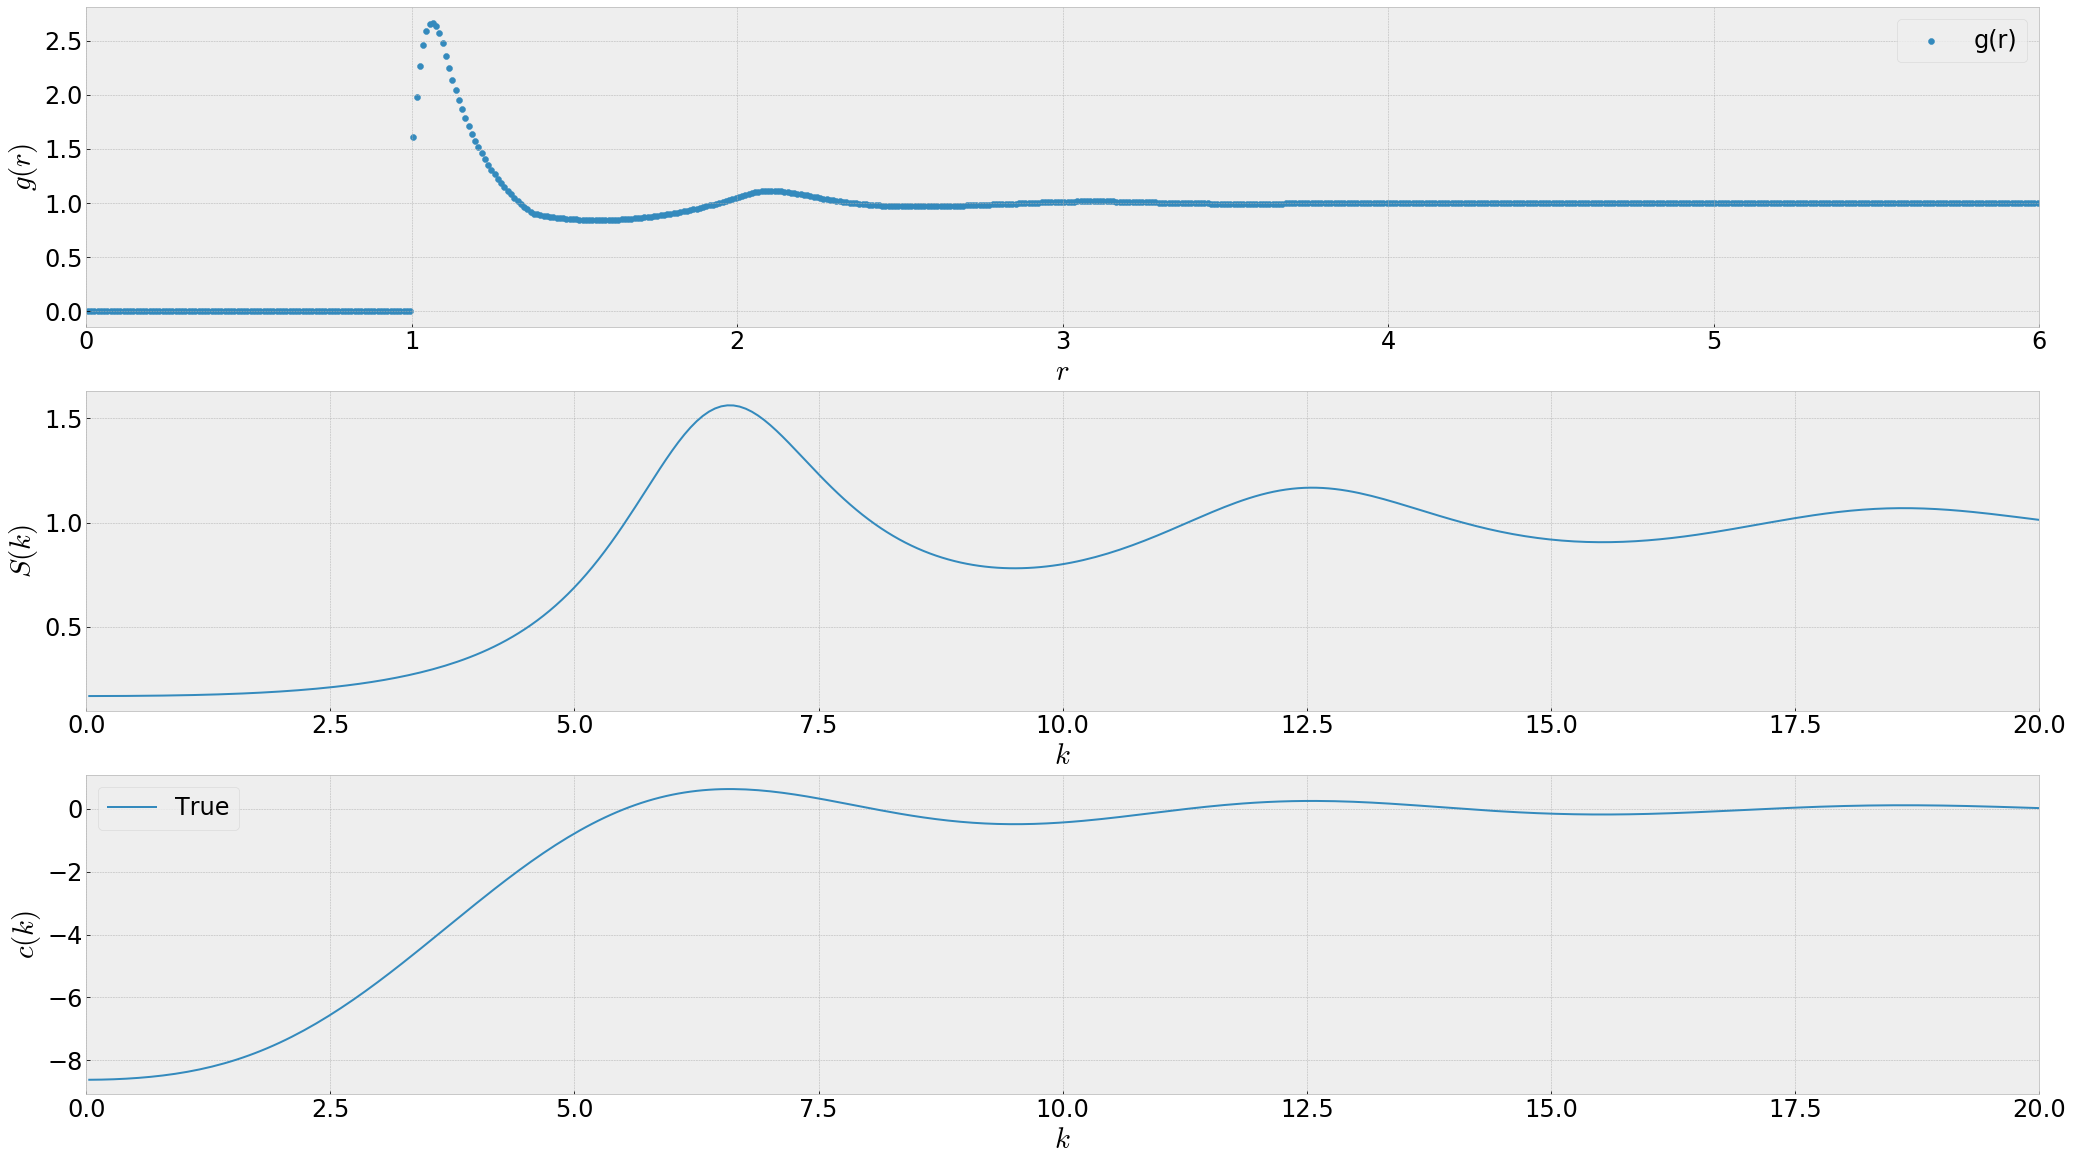

In [73]:
# plt.figure(figsize=(35,20), dpi= 80, facecolor='g', edgecolor='r')
plt.figure(figsize=(35,20))

plt.subplot(3,1,1)
plt.scatter(r_array, g_r, label='g(r)')
#plt.scatter(r_array, np.exp(-u_tmp), label='Diluted')
plt.ylabel('$g(r)$')
plt.xlabel('$r$')
plt.xlim(0,6)
#plt.ylim(0.95,1.3)
plt.legend()
# plt.grid()

S_k = 1+dimless_dens*c_k/(1-dimless_dens*c_k)
plt.subplot(3,1,2)
plt.plot(k_array,S_k)
plt.ylabel('$S(k)$')
plt.xlabel('$k$')
plt.xlim(0,20)
# plt.grid()

c_k_tmp = initial_c_k(k_array)
plt.subplot(3,1,3)
plt.plot(k_array,c_k, label = 'True')
#plt.plot(k_array,c_k_tmp, label = 'Initial')
plt.ylabel('$c(k)$')
plt.xlabel('$k$')
plt.xlim(0,20)
plt.legend()
# plt.grid()

# plt.tight_layout()

* final energy =  -1.0047011533020431
* final pressure =  0.0
* peak of g(r) =  2.665284292804131
* peak of S(k) =  1.5622043062368463


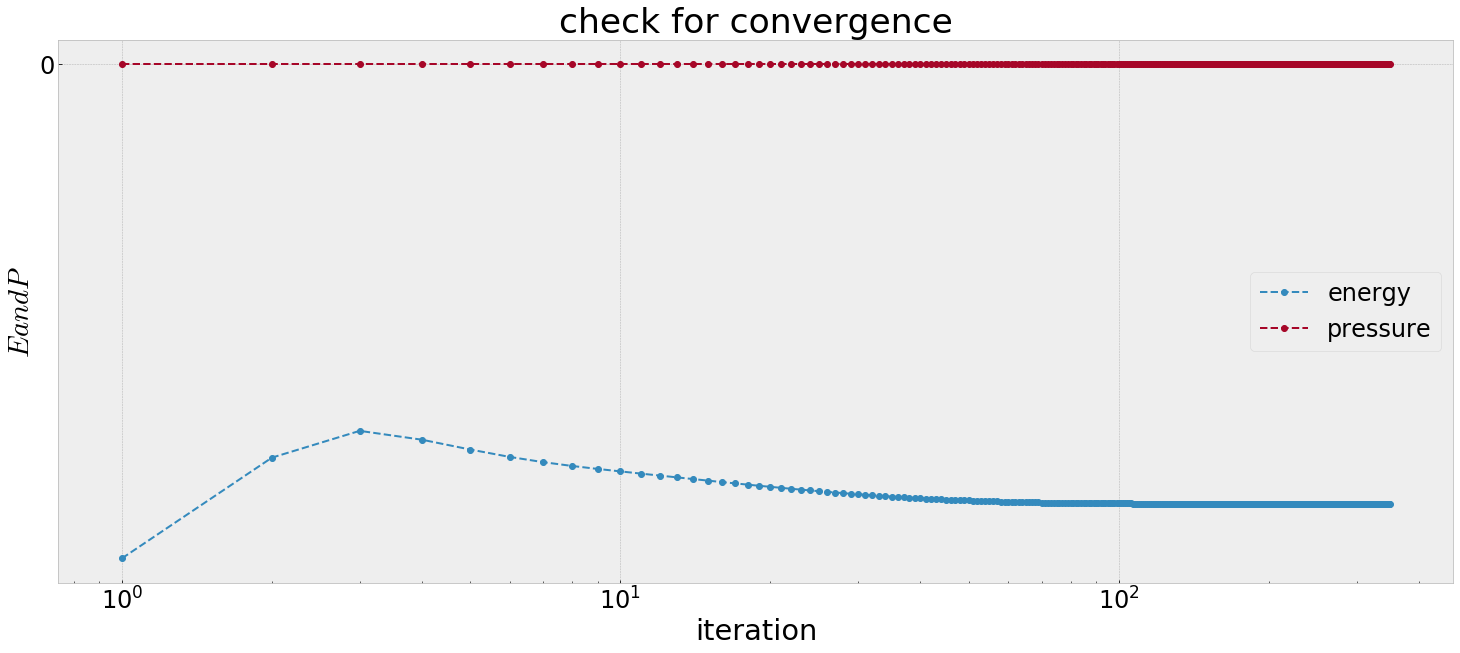

In [74]:
plt.figure(figsize=(25,10))

plt.plot(np.arange(num_iterations)+1, energy_iter, 'o--', label='energy')
plt.plot(np.arange(num_iterations)+1, pressure_iter, 'o--', label='pressure')
plt.yscale('symlog')
plt.xscale('log')
plt.ylabel('$E and P$')
plt.xlabel('iteration')
plt.title("check for convergence")
plt.legend()
print('* final energy = ',energy_iter[len(energy_iter)-1])
print('* final pressure = ',pressure_iter[len(energy_iter)-1])
print('* peak of g(r) = ',np.max(g_r))
print('* peak of S(k) = ',np.max(S_k))

### <a id="saving"></a> Salva i risultati


In [75]:
#Static Structure factor
#S_path = "./Confronto_Hansen/S_gamma_200.out"
#S_id = open(S_path, 'w+')
#S_data = np.array([k_array,S_k]).T
#np.savetxt('S_Yukawa_Pe10_kappa2_Gamma20_eta0p3.out',S_data)
#S_id.close()

#Pair functions results
c_data = np.array([k_array,c_k]).T
np.savetxt('c_k.in',c_data)
#c_s_data = np.array([k_array,c_s_k]).T
#np.savetxt('c_s_k.in',c_s_data)
#c_r_data = np.array([r_array,FT_k_2_r(c_k)]).T
#np.savetxt('c_r_Gamma200.in',c_r_data)
#g_data = np.array([r_array,g_r]).T
#np.savetxt('g_HNC_Yukawa_Nohydro_Pe10_kappa2_Gamma500_eta0p1.out',g_data)

### Saving less point to save space

In [77]:
'''
# Save g up to r = 5
Nmax = 500
print('Save g(r) up to r equal:   ',r_array[Nmax])
g_red = np.zeros(Nmax)
r_red = np.zeros(Nmax)

for i in range(Nmax):
    r_red[i] = r_array[i]
    g_red[i] = g_r[i]


g_data_red = np.array([r_red,g_red]).T
np.savetxt('g_HNC_Yukawa_Nohydro_Pe10_kappa2_Gamma150_eta0p4.out',g_data_red)    
'''

"\n# Save g up to r = 5\nNmax = 500\nprint('Save g(r) up to r equal:   ',r_array[Nmax])\ng_red = np.zeros(Nmax)\nr_red = np.zeros(Nmax)\n\nfor i in range(Nmax):\n    r_red[i] = r_array[i]\n    g_red[i] = g_r[i]\n\n\ng_data_red = np.array([r_red,g_red]).T\nnp.savetxt('g_HNC_Yukawa_Nohydro_Pe10_kappa2_Gamma150_eta0p4.out',g_data_red)    \n"

In [78]:
'''
Nmax = 1000
print('Save S(k) up to k equal:   ',k_array[Nmax])
S_red = np.zeros(Nmax)
k_red = np.zeros(Nmax)

for i in range(Nmax):
    k_red[i] = k_array[i]
    S_red[i] = S_k[i]


S_data_red = np.array([k_red,S_red]).T
np.savetxt('S_HS_Pe16_eta0p4.out',S_data_red)    
'''

"\nNmax = 1000\nprint('Save S(k) up to k equal:   ',k_array[Nmax])\nS_red = np.zeros(Nmax)\nk_red = np.zeros(Nmax)\n\nfor i in range(Nmax):\n    k_red[i] = k_array[i]\n    S_red[i] = S_k[i]\n\n\nS_data_red = np.array([k_red,S_red]).T\nnp.savetxt('S_HS_Pe16_eta0p4.out',S_data_red)    \n"

____
[Back to top.](#top)
____